In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

In [ ]:
X = np.load("/content/drive/MyDrive/Mammogram_Project/X.npy")
Y = np.load("/content/drive/MyDrive/Mammogram_Project/Y.npy")

print("X Shape :", X.shape)
print("Y Shape :", Y.shape)

X Shape : (3242, 256, 256, 1)
Y Shape : (3242, 256, 256, 1)


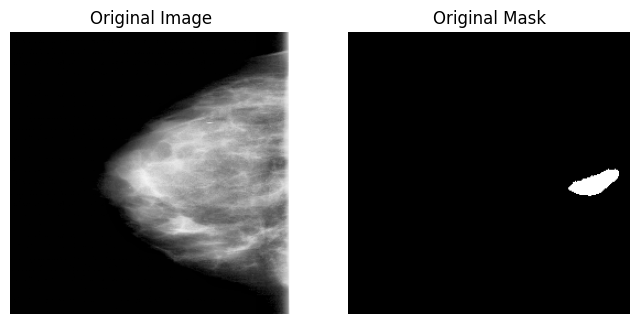

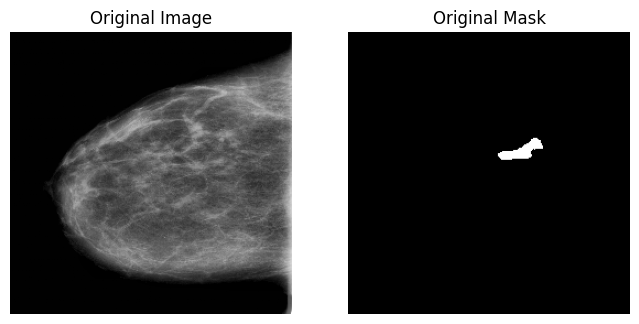

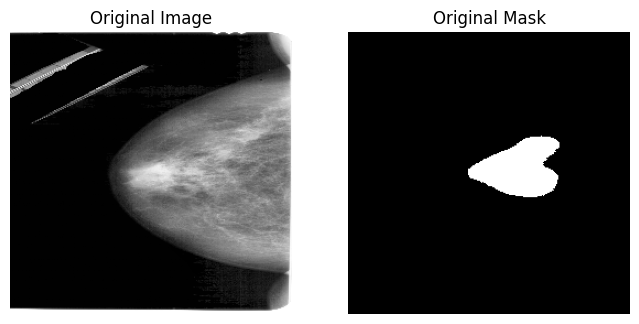

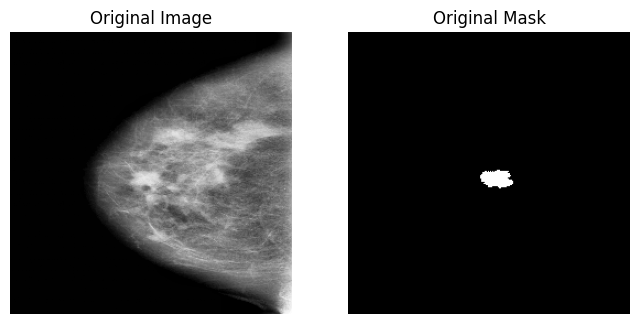

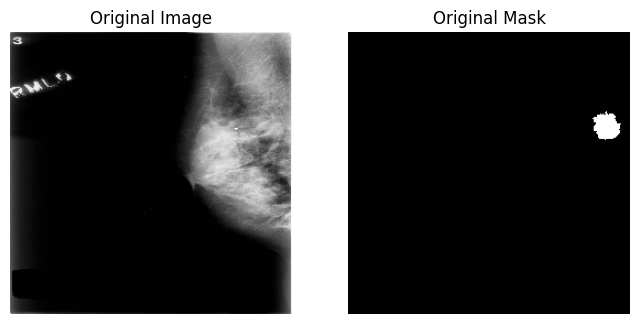

In [ ]:
for i in range(5):

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(X[i].squeeze(), cmap="gray")
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(Y[i].squeeze(), cmap="gray")
    plt.title("Original Mask")
    plt.axis("off")

    plt.show()

In [ ]:
ROI_SIZE = 128

ROI_X = []
ROI_Y = []

for i in tqdm(range(len(X))):

    image = X[i].squeeze()
    mask = Y[i].squeeze().astype(np.uint8)

    # Find lesion pixels
    ys, xs = np.where(mask > 0)

    # Skip if mask is empty
    if len(xs) == 0:
        continue

    # Bounding box
    x_min = xs.min()
    x_max = xs.max()

    y_min = ys.min()
    y_max = ys.max()

    lesion_w = x_max - x_min + 1
    lesion_h = y_max - y_min + 1

    # Adaptive padding
    padding = int(max(lesion_w, lesion_h) * 0.5)

    padding = max(20, padding)
    padding = min(60, padding)

    # Expanded bounding box
    x1 = max(0, x_min - padding)
    y1 = max(0, y_min - padding)

    x2 = min(image.shape[1], x_max + padding)
    y2 = min(image.shape[0], y_max + padding)

    roi_img = image[y1:y2, x1:x2]
    roi_mask = mask[y1:y2, x1:x2]

    roi_img = cv2.resize(
        roi_img,
        (ROI_SIZE, ROI_SIZE),
        interpolation=cv2.INTER_AREA
    )

    roi_mask = cv2.resize(
        roi_mask,
        (ROI_SIZE, ROI_SIZE),
        interpolation=cv2.INTER_NEAREST
    )

    ROI_X.append(roi_img)
    ROI_Y.append(roi_mask)

100%|██████████| 3242/3242 [00:01<00:00, 2391.16it/s]


In [ ]:
ROI_X = np.array(ROI_X, dtype=np.float32)[..., np.newaxis]
ROI_Y = np.array(ROI_Y, dtype=np.uint8)[..., np.newaxis]

print("ROI_X Shape:", ROI_X.shape)
print("ROI_Y Shape:", ROI_Y.shape)

ROI_X Shape: (3242, 128, 128, 1)
ROI_Y Shape: (3242, 128, 128, 1)


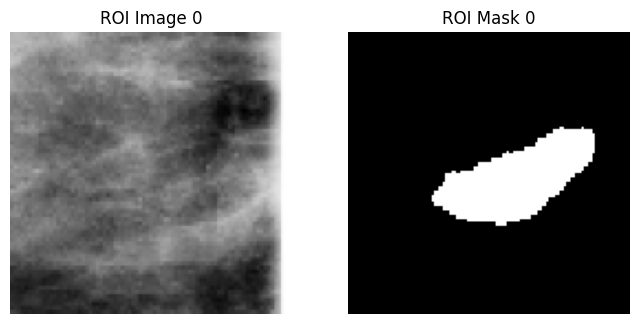

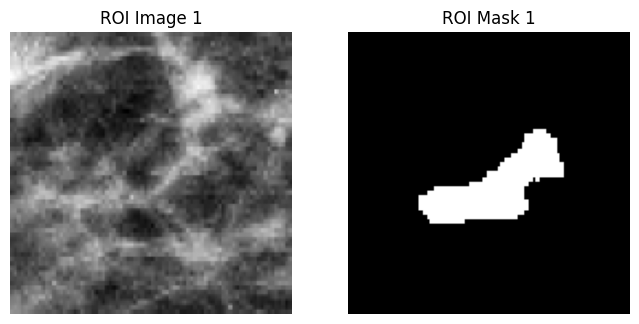

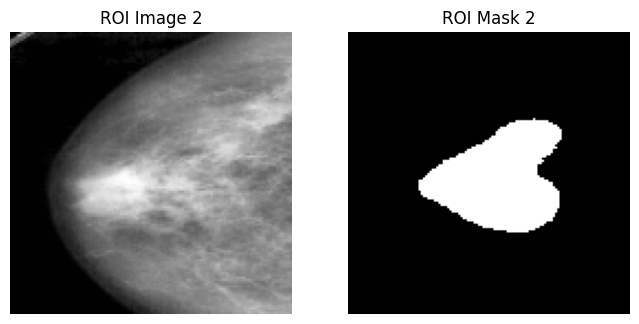

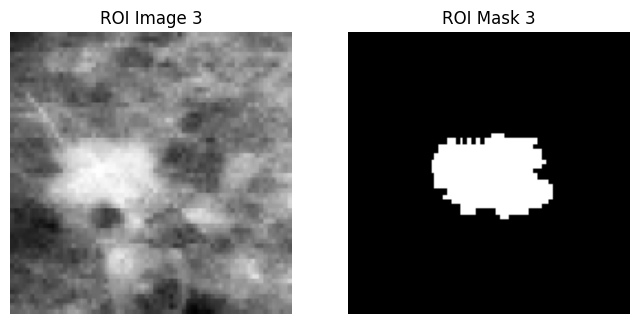

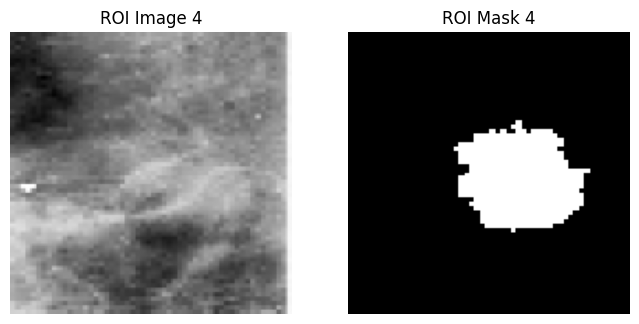

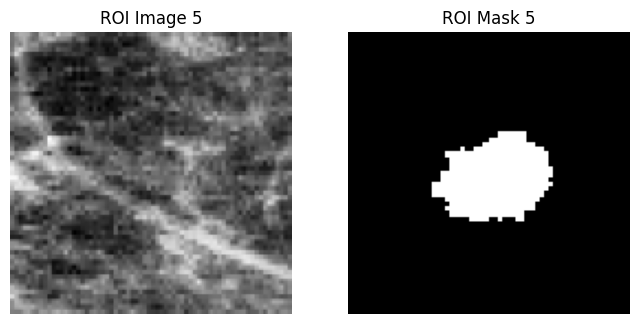

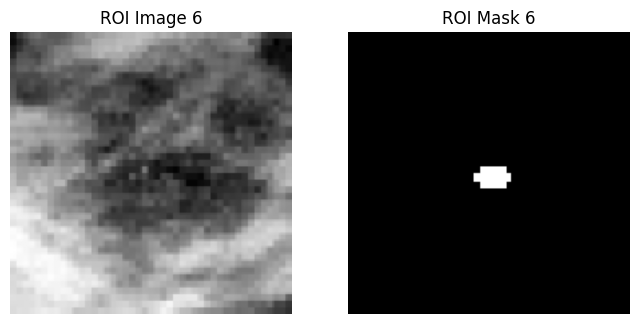

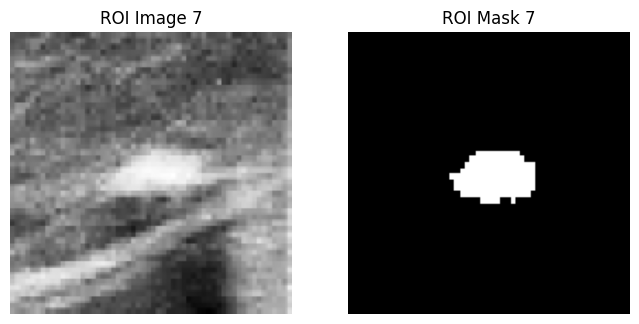

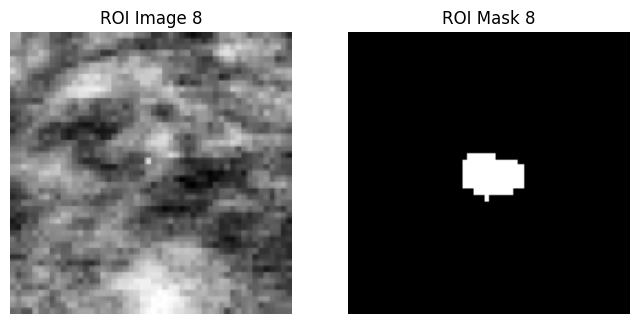

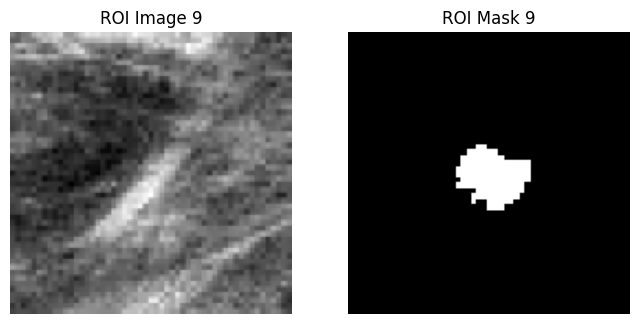

In [ ]:
for i in range(10):

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(ROI_X[i].squeeze(), cmap="gray")
    plt.title(f"ROI Image {i}")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(ROI_Y[i].squeeze(), cmap="gray")
    plt.title(f"ROI Mask {i}")
    plt.axis("off")

    plt.show()

In [ ]:
import os
import numpy as np

save_dir = "/content/drive/MyDrive/Mammogram_Project"
os.makedirs(save_dir, exist_ok=True)

np.save(os.path.join(save_dir, "NEW_ROI_X.npy"), ROI_X)
np.save(os.path.join(save_dir, "NEW_ROI_Y.npy"), ROI_Y)

print("✅ NEW_ROI_X.npy saved successfully!")
print("✅ NEW_ROI_Y.npy saved successfully!")

✅ NEW_ROI_X.npy saved successfully!
✅ NEW_ROI_Y.npy saved successfully!


In [ ]:
NEW_ROI_X = np.load("/content/drive/MyDrive/Mammogram_Project/NEW_ROI_X.npy")
NEW_ROI_Y = np.load("/content/drive/MyDrive/Mammogram_Project/NEW_ROI_Y.npy")

print(NEW_ROI_X.shape)
print(NEW_ROI_Y.shape)

(3242, 128, 128, 1)
(3242, 128, 128, 1)


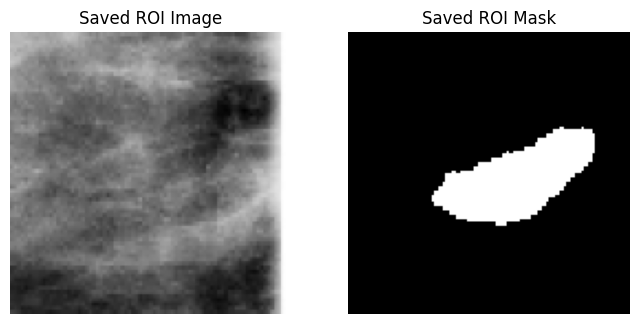

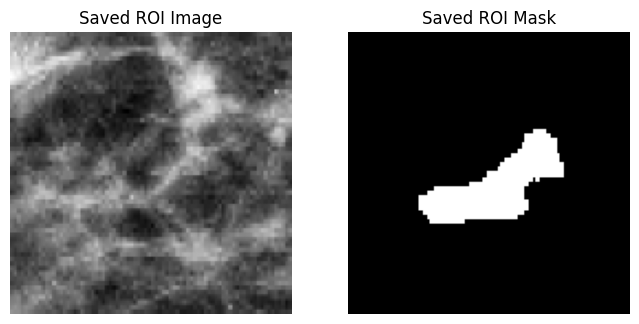

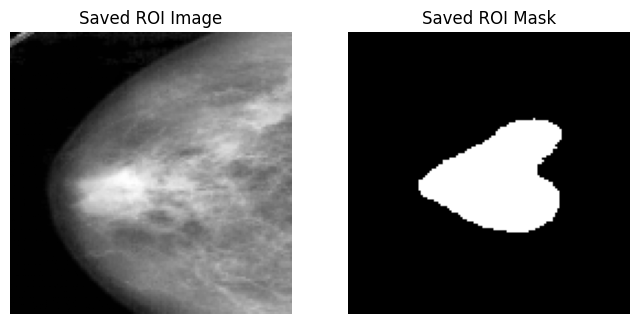

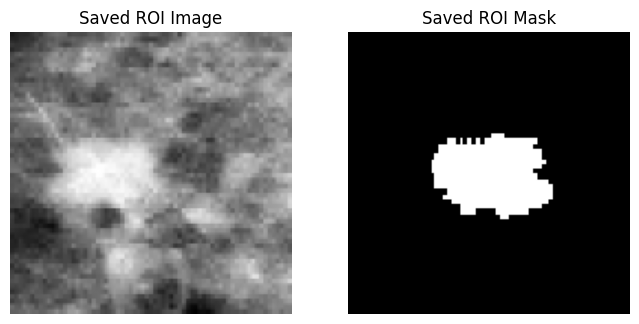

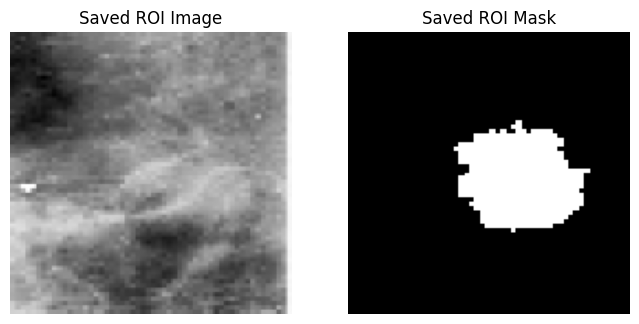

In [ ]:
import matplotlib.pyplot as plt

for i in range(5):

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(NEW_ROI_X[i].squeeze(), cmap="gray")
    plt.title("Saved ROI Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(NEW_ROI_Y[i].squeeze(), cmap="gray")
    plt.title("Saved ROI Mask")
    plt.axis("off")

    plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, Y_train, Y_temp = train_test_split(
    NEW_ROI_X,
    NEW_ROI_Y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp,
    Y_temp,
    test_size=0.5,
    random_state=42,
    shuffle=True
)

print("Train      :", X_train.shape)
print("Validation :", X_val.shape)
print("Test       :", X_test.shape)

Train      : (2593, 128, 128, 1)
Validation : (324, 128, 128, 1)
Test       : (325, 128, 128, 1)


In [ ]:
import torch
from torch.utils.data import Dataset

class MammogramDataset(Dataset):

    def __init__(self, images, masks):
        self.images = images
        self.masks = masks

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image = torch.tensor(
            self.images[idx],
            dtype=torch.float32
        ).permute(2, 0, 1)

        mask = torch.tensor(
            self.masks[idx],
            dtype=torch.float32
        ).permute(2, 0, 1)

        return image, mask

In [ ]:
from torch.utils.data import DataLoader

batch_size = 16

train_dataset = MammogramDataset(X_train, Y_train)
val_dataset = MammogramDataset(X_val, Y_val)
test_dataset = MammogramDataset(X_test, Y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=True
)

print("Train batches :", len(train_loader))
print("Validation batches :", len(val_loader))
print("Test batches :", len(test_loader))

Train batches : 163
Validation batches : 21
Test batches : 21


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [ ]:
import torch
import torch.nn as nn

# ----------------------------
# Double Convolution
# ----------------------------
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


# ----------------------------
# Attention Gate
# ----------------------------
class AttentionBlock(nn.Module):

    def __init__(self, F_g, F_l, F_int):
        super().__init__()

        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, bias=False),
            nn.BatchNorm2d(F_int)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, bias=False),
            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, bias=False),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):

        g1 = self.W_g(g)
        x1 = self.W_x(x)

        psi = self.relu(g1 + x1)
        psi = self.psi(psi)

        return x * psi


# ----------------------------
# Up Block
# ----------------------------
class Up(nn.Module):

    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_ch,
            out_ch,
            kernel_size=2,
            stride=2
        )

    def forward(self, x):
        return self.up(x)


# ----------------------------
# Attention U-Net
# ----------------------------
class AttentionUNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.pool = nn.MaxPool2d(2)

        # Encoder
        self.c1 = DoubleConv(1, 32)
        self.c2 = DoubleConv(32, 64)
        self.c3 = DoubleConv(64, 128)
        self.c4 = DoubleConv(128, 256)

        # Bottleneck
        self.center = DoubleConv(256, 512)

        # Decoder
        self.up4 = Up(512, 256)
        self.att4 = AttentionBlock(256, 256, 128)
        self.d4 = DoubleConv(512, 256)

        self.up3 = Up(256, 128)
        self.att3 = AttentionBlock(128, 128, 64)
        self.d3 = DoubleConv(256, 128)

        self.up2 = Up(128, 64)
        self.att2 = AttentionBlock(64, 64, 32)
        self.d2 = DoubleConv(128, 64)

        self.up1 = Up(64, 32)
        self.att1 = AttentionBlock(32, 32, 16)
        self.d1 = DoubleConv(64, 32)

        self.final = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):

        c1 = self.c1(x)
        p1 = self.pool(c1)

        c2 = self.c2(p1)
        p2 = self.pool(c2)

        c3 = self.c3(p2)
        p3 = self.pool(c3)

        c4 = self.c4(p3)
        p4 = self.pool(c4)

        center = self.center(p4)

        u4 = self.up4(center)
        a4 = self.att4(u4, c4)
        d4 = self.d4(torch.cat([u4, a4], dim=1))

        u3 = self.up3(d4)
        a3 = self.att3(u3, c3)
        d3 = self.d3(torch.cat([u3, a3], dim=1))

        u2 = self.up2(d3)
        a2 = self.att2(u2, c2)
        d2 = self.d2(torch.cat([u2, a2], dim=1))

        u1 = self.up1(d2)
        a1 = self.att1(u1, c1)
        d1 = self.d1(torch.cat([u1, a1], dim=1))

        return self.final(d1)

In [ ]:
model = AttentionUNet().to(device)

print(model)

AttentionUNet(
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (c1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (c2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats

In [ ]:
import torch
import torch.nn as nn

# Dice Loss
def dice_loss(pred, target, smooth=1e-6):

    pred = torch.sigmoid(pred)

    pred = pred.contiguous().view(-1)
    target = target.contiguous().view(-1)

    intersection = (pred * target).sum()

    dice = (2. * intersection + smooth) / (
        pred.sum() + target.sum() + smooth
    )

    return 1 - dice


# BCE Loss
bce_loss = nn.BCEWithLogitsLoss()


# Total Loss
def total_loss(pred, target):

    return bce_loss(pred, target) + dice_loss(pred, target)

print("Loss Functions Loaded Successfully!")

Loss Functions Loaded Successfully!


In [ ]:
def calculate_metrics(pred, target, smooth=1e-6):

    pred = (torch.sigmoid(pred) > 0.5).float()

    pred = pred.view(-1)
    target = target.view(-1)

    TP = (pred * target).sum()
    TN = ((1-pred)*(1-target)).sum()
    FP = (pred*(1-target)).sum()
    FN = ((1-pred)*target).sum()

    accuracy = (TP + TN) / (TP + TN + FP + FN + smooth)

    precision = TP / (TP + FP + smooth)

    recall = TP / (TP + FN + smooth)

    f1 = 2 * precision * recall / (precision + recall + smooth)

    iou = TP / (TP + FP + FN + smooth)

    dice = (2 * TP) / (2 * TP + FP + FN + smooth)

    return (
        accuracy.item(),
        precision.item(),
        recall.item(),
        f1.item(),
        iou.item(),
        dice.item()
    )

In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.amp import GradScaler

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

scheduler = ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

scaler = GradScaler("cuda")

In [ ]:
import os

save_dir = "/content/drive/MyDrive/ROI_AttentionUNet"

os.makedirs(save_dir, exist_ok=True)

best_model_path = os.path.join(
    save_dir,
    "best_attention_unet_roi.pth"
)

checkpoint_path = os.path.join(
    save_dir,
    "checkpoint_roi.pth"
)

print(best_model_path)
print(checkpoint_path)

/content/drive/MyDrive/ROI_AttentionUNet/best_attention_unet_roi.pth
/content/drive/MyDrive/ROI_AttentionUNet/checkpoint_roi.pth


In [ ]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_dice": [],
    "val_dice": [],
    "val_iou": [],
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": []
}

In [ ]:
# IMPORTANT: If you encounter 'NameError: name 'train_loader' is not defined',
# please ensure that all preceding cells, especially the one defining
# `train_dataset` and `DataLoader`, have been executed successfully.
from tqdm import tqdm
import torch
from torch.cuda.amp import autocast

num_epochs = 50

best_dice = 0.0
patience = 8
counter = 0

for epoch in range(num_epochs):

    ##################################
    # TRAIN
    ##################################

    model.train()

    train_loss = 0.0
    train_dice = 0.0

    train_bar = tqdm(train_loader)

    for images, masks in train_bar:

        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast():

            outputs = model(images)
            loss = total_loss(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

        _, _, _, _, _, dice = calculate_metrics(outputs, masks)

        train_dice += dice

        train_bar.set_description(
            f"Epoch {epoch+1}/{num_epochs}"
        )

        train_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    train_loss /= len(train_loader)
    train_dice /= len(train_loader)

    ##################################
    # VALIDATION
    ##################################

    model.eval()

    val_loss = 0.0
    val_acc = 0.0
    val_precision = 0.0
    val_recall = 0.0
    val_f1 = 0.0
    val_iou = 0.0
    val_dice = 0.0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            with autocast():

                outputs = model(images)
                loss = total_loss(outputs, masks)

            val_loss += loss.item()

            acc, prec, rec, f1, iou, dice = calculate_metrics(
                outputs,
                masks
            )

            val_acc += acc
            val_precision += prec
            val_recall += rec
            val_f1 += f1
            val_iou += iou
            val_dice += dice

    val_loss /= len(val_loader)
    val_acc /= len(val_loader)
    val_precision /= len(val_loader)
    val_recall /= len(val_loader)
    val_f1 /= len(val_loader)
    val_iou /= len(val_loader)
    val_dice /= len(val_loader)

    ##################################
    # Scheduler
    ##################################

    scheduler.step(val_dice)

    ##################################
    # Save History
    ##################################

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_dice"].append(train_dice)
    history["val_dice"].append(val_dice)

    history["val_iou"].append(val_iou)

    history["accuracy"].append(val_acc)
    history["precision"].append(val_precision)
    history["recall"].append(val_recall)
    history["f1"].append(val_f1)

    ##################################
    # Print Results
    ##################################

    print("\n" + "="*50)

    print(f"Epoch {epoch+1}/{num_epochs}")

    print(f"Train Loss      : {train_loss:.4f}")
    print(f"Train Dice      : {train_dice:.4f}")

    print(f"Validation Loss : {val_loss:.4f}")
    print(f"Validation Dice : {val_dice:.4f}")
    print(f"Validation IoU  : {val_iou:.4f}")

    print(f"Accuracy        : {val_acc:.4f}")
    print(f"Precision       : {val_precision:.4f}")
    print(f"Recall          : {val_recall:.4f}")
    print(f"F1 Score        : {val_f1:.4f}")

    ##################################
    # Save Best Model
    ##################################

    if val_dice > best_dice:

        best_dice = val_dice
        counter = 0

        torch.save(
            model.state_dict(),
            best_model_path
        )

        torch.save({

            "epoch": epoch + 1,

            "model_state_dict":
                model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "scheduler_state_dict":
                scheduler.state_dict(),

            "best_dice":
                best_dice,

            "history":
                history

        }, checkpoint_path)

        print("✅ Best Model Saved!")

    else:

        counter += 1

    ##################################
    # Early Stopping
    ##################################

    if counter >= patience:

        print("\n🛑 Early stopping triggered!")

        break


print("\n🎉 Training Finished!")

print(f"Best Validation Dice : {best_dice:.4f}")

  0%|          | 0/163 [00:00<?, ?it/s]/tmp/ipykernel_4882/2319371977.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/50: 100%|██████████| 163/163 [00:13<00:00, 12.06it/s, loss=1.1280]
/tmp/ipykernel_4882/2319371977.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Epoch 1/50
Train Loss      : 1.2736
Train Dice      : 0.6423
Validation Loss : 1.1701
Validation Dice : 0.7066
Validation IoU  : 0.5486
Accuracy        : 0.9448
Precision       : 0.5990
Recall          : 0.8691
F1 Score        : 0.7066
✅ Best Model Saved!


Epoch 2/50: 100%|██████████| 163/163 [00:09<00:00, 17.19it/s, loss=0.9837]



Epoch 2/50
Train Loss      : 1.1235
Train Dice      : 0.7271
Validation Loss : 1.0838
Validation Dice : 0.7474
Validation IoU  : 0.5988
Accuracy        : 0.9560
Precision       : 0.6718
Recall          : 0.8474
F1 Score        : 0.7474
✅ Best Model Saved!


Epoch 3/50: 100%|██████████| 163/163 [00:09<00:00, 16.83it/s, loss=0.8171]


...


Epoch 25/50
Train Loss      : 0.1922
Train Dice      : 0.9249
Validation Loss : 0.3781
Validation Dice : 0.8003
Validation IoU  : 0.6689
Accuracy        : 0.9701
Precision       : 0.8283
Recall          : 0.7767
F1 Score        : 0.8003


Epoch 26/50: 100%|██████████| 163/163 [00:09<00:00, 17.09it/s, loss=0.3822]



Epoch 26/50
Train Loss      : 0.1825
Train Dice      : 0.9294
Validation Loss : 0.3876
Validation Dice : 0.7909
Validation IoU  : 0.6559
Accuracy        : 0.9696
Precision       : 0.8464
Recall          : 0.7447
F1 Score        : 0.7909


Epoch 27/50: 100%|██████████| 163/163 [00:09<00:00, 17.06it/s, loss=0.1878]



Epoch 27/50
Train Loss      : 0.1765
Train Dice      : 0.9307
Validation Loss : 0.3765
Validation Dice : 0.7954
Validation IoU  : 0.6622
Accuracy        : 0.9700
Precision       : 0.8423
Recall          : 0.7563
F1 Score        : 0.7954

🛑 Early stopping triggered!

🎉 Training Finished!
Best Validation Dice : 0.8074


In [ ]:
model.load_state_dict(torch.load(best_model_path))
model.eval()

AttentionUNet(
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (c1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (c2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats

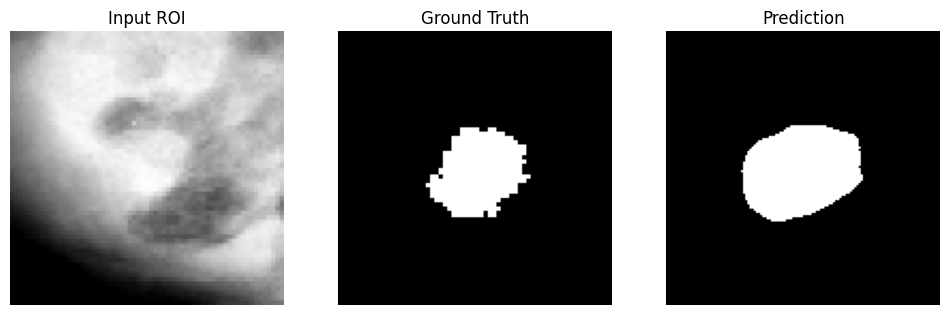

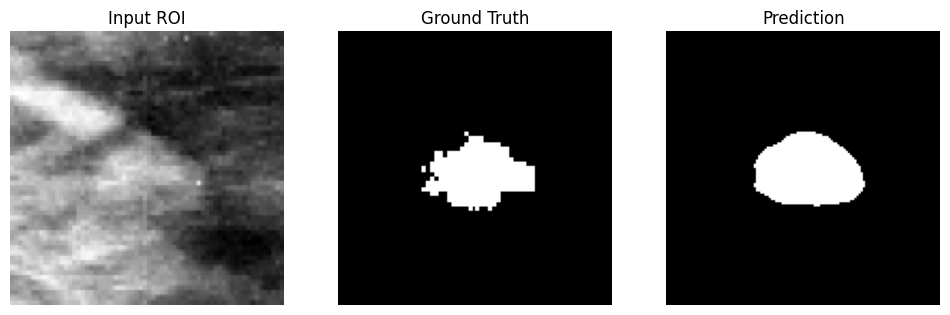

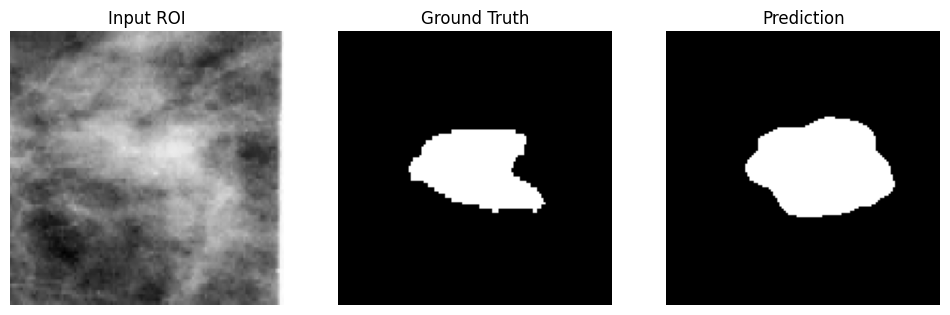

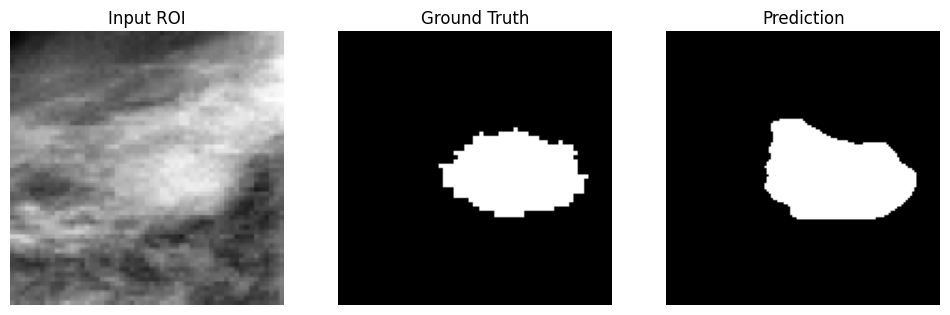

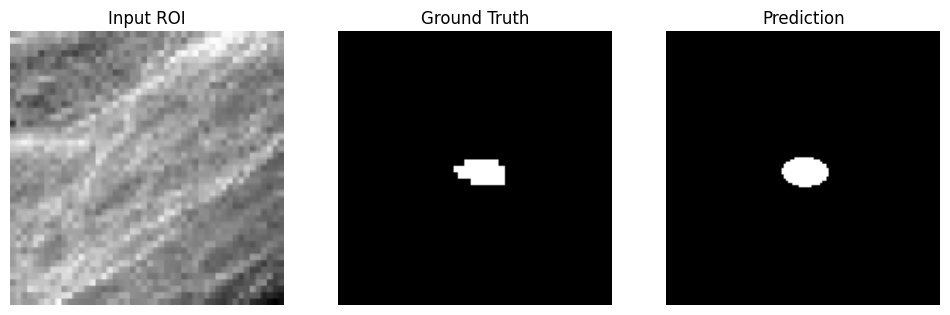

In [ ]:
import matplotlib.pyplot as plt
import torch

model.eval()

images, masks = next(iter(test_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = (torch.sigmoid(outputs) > 0.5).float()

num_images = 5   # Change to 10 if you want

for i in range(num_images):

    plt.figure(figsize=(12,4))

    # Input
    plt.subplot(1,3,1)
    plt.imshow(images[i].cpu().squeeze(), cmap="gray")
    plt.title("Input ROI")
    plt.axis("off")

    # Ground Truth
    plt.subplot(1,3,2)
    plt.imshow(masks[i].cpu().squeeze(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    # Prediction
    plt.subplot(1,3,3)
    plt.imshow(preds[i].cpu().squeeze(), cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

    plt.show()

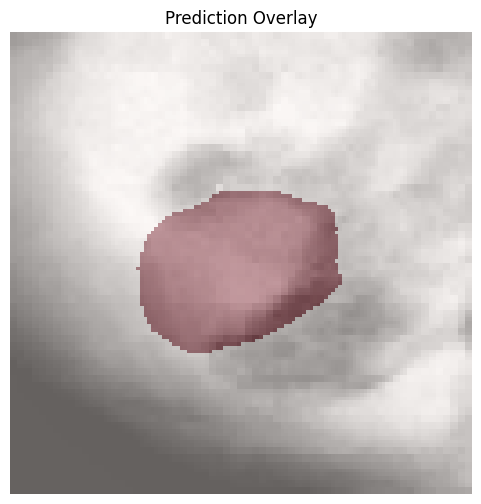

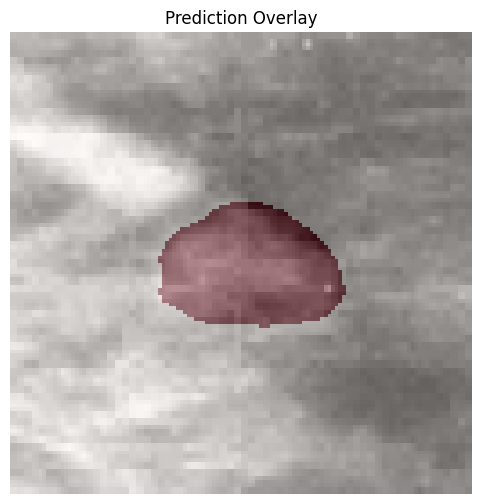

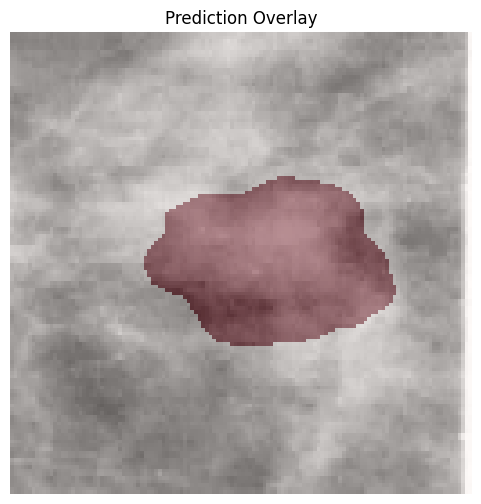

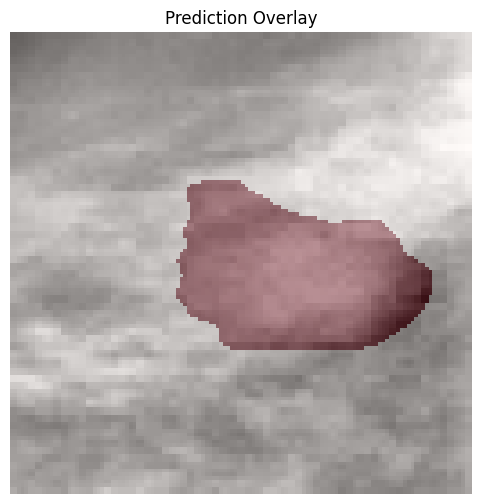

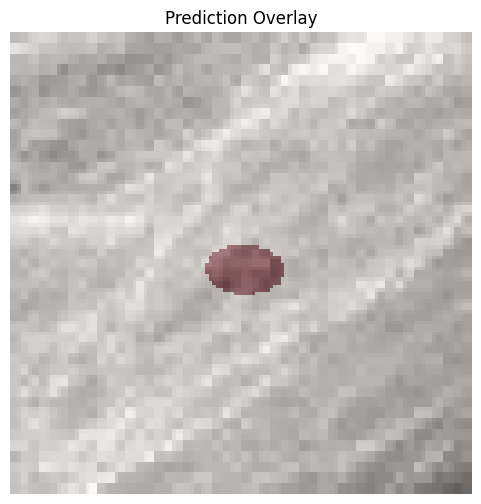

In [ ]:
import matplotlib.pyplot as plt

for i in range(5):

    img = images[i].cpu().squeeze().numpy()
    pred = preds[i].cpu().squeeze().numpy()

    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap="gray")
    plt.imshow(pred, cmap="Reds", alpha=0.4)
    plt.title("Prediction Overlay")
    plt.axis("off")
    plt.show()

In [ ]:
import torch

checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint)
model.to(device)
model.eval()

print("✅ Best model loaded!")

✅ Best model loaded!


In [ ]:
model.eval()

test_loss = 0
test_acc = 0
test_precision = 0
test_recall = 0
test_f1 = 0
test_iou = 0
test_dice = 0

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        loss = total_loss(outputs, masks)
        test_loss += loss.item()

        acc, prec, rec, f1, iou, dice = calculate_metrics(outputs, masks)

        test_acc += acc
        test_precision += prec
        test_recall += rec
        test_f1 += f1
        test_iou += iou
        test_dice += dice

# Average metrics
test_loss /= len(test_loader)
test_acc /= len(test_loader)
test_precision /= len(test_loader)
test_recall /= len(test_loader)
test_f1 /= len(test_loader)
test_iou /= len(test_loader)
test_dice /= len(test_loader)

print("\n========== Test Results ==========")
print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Dice      : {test_dice:.4f}")
print(f"Test IoU       : {test_iou:.4f}")
print(f"Accuracy       : {test_acc:.4f}")
print(f"Precision      : {test_precision:.4f}")
print(f"Recall         : {test_recall:.4f}")
print(f"F1 Score       : {test_f1:.4f}")


========== Test Results ==========
Test Loss      : 0.4105
Test Dice      : 0.7975
Test IoU       : 0.6681
Accuracy       : 0.9681
Precision      : 0.7885
Recall         : 0.8105
F1 Score       : 0.7975


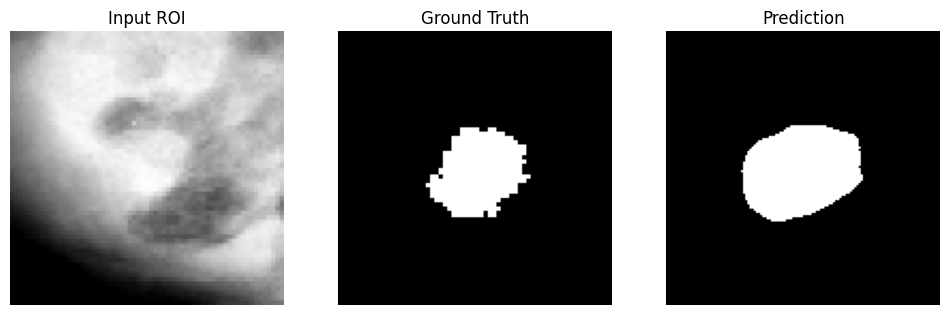

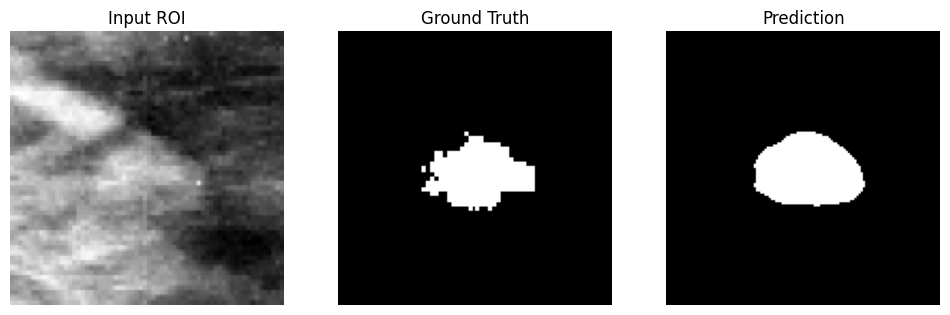

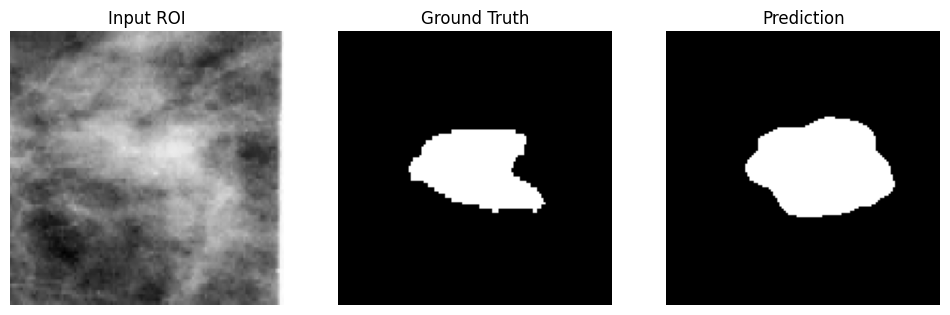

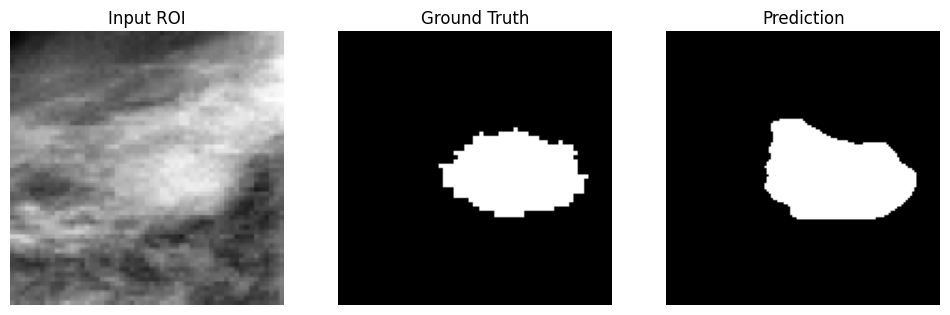

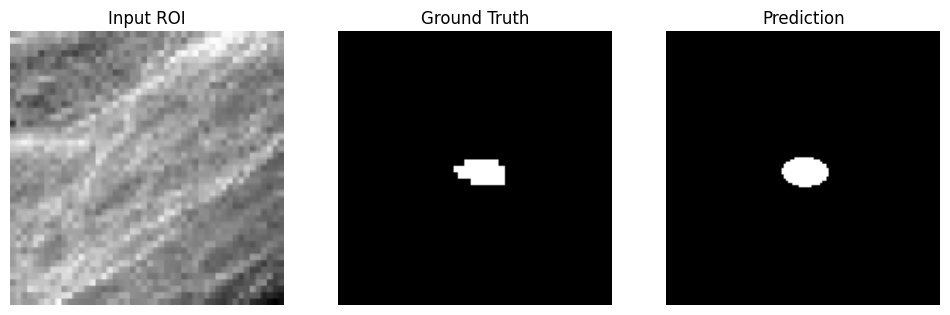

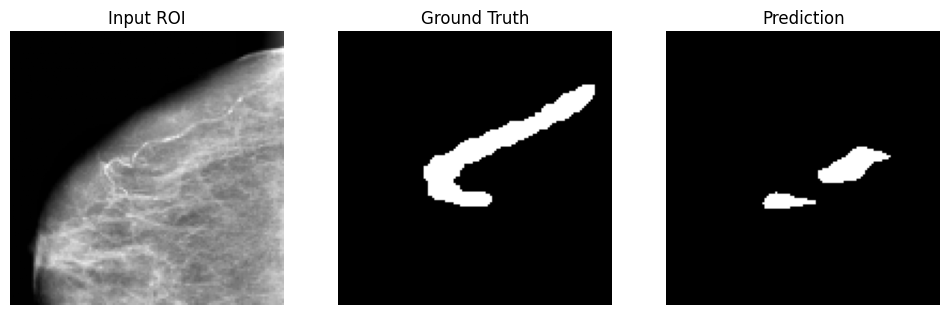

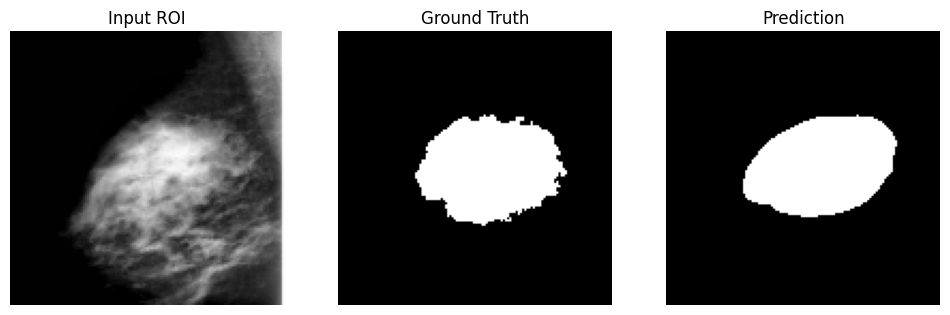

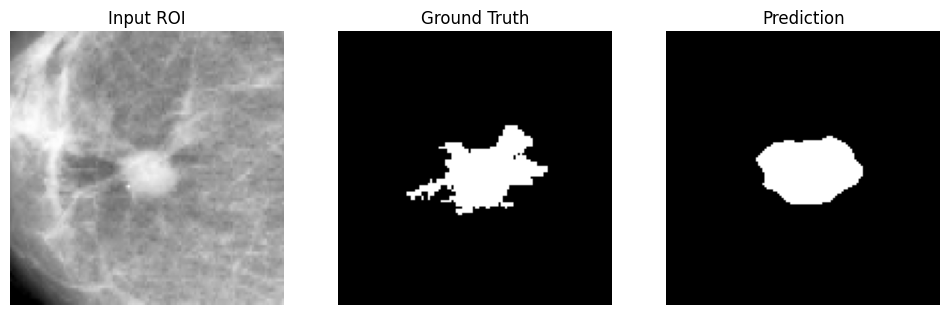

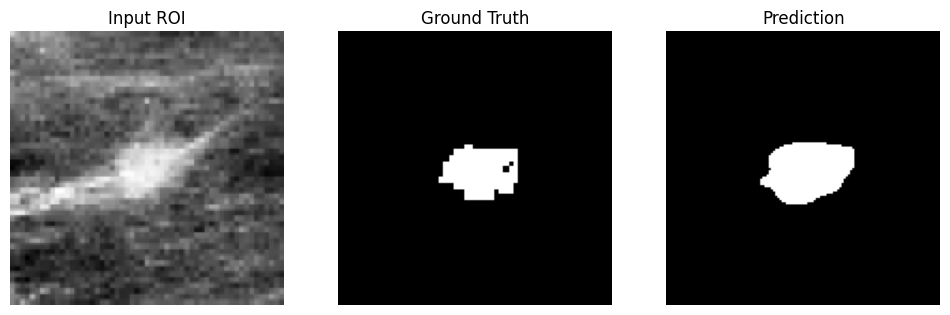

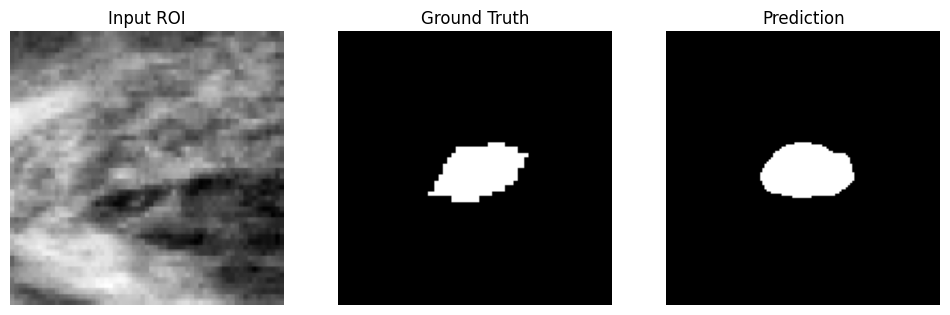

In [ ]:
import matplotlib.pyplot as plt
import torch

model.eval()

images, masks = next(iter(test_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = (torch.sigmoid(outputs) > 0.5).float()

num_images = 10

for i in range(num_images):

    plt.figure(figsize=(12,4))

    # Input ROI
    plt.subplot(1,3,1)
    plt.imshow(images[i].cpu().squeeze(), cmap="gray")
    plt.title("Input ROI")
    plt.axis("off")

    # Ground Truth
    plt.subplot(1,3,2)
    plt.imshow(masks[i].cpu().squeeze(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    # Prediction
    plt.subplot(1,3,3)
    plt.imshow(preds[i].cpu().squeeze(), cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

    plt.show()

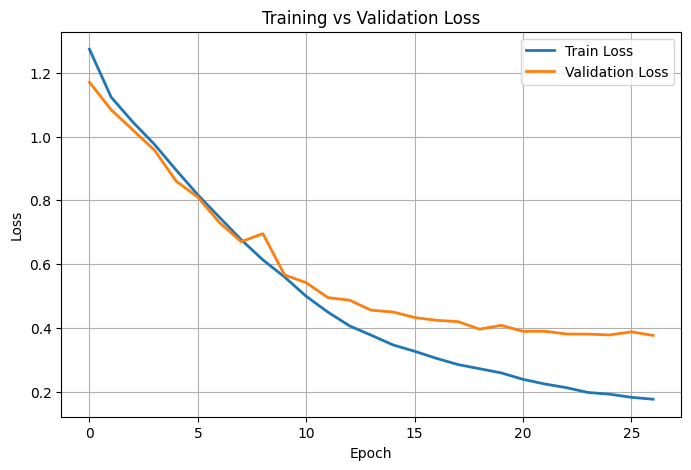

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history["train_loss"], label="Train Loss", linewidth=2)
plt.plot(history["val_loss"], label="Validation Loss", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

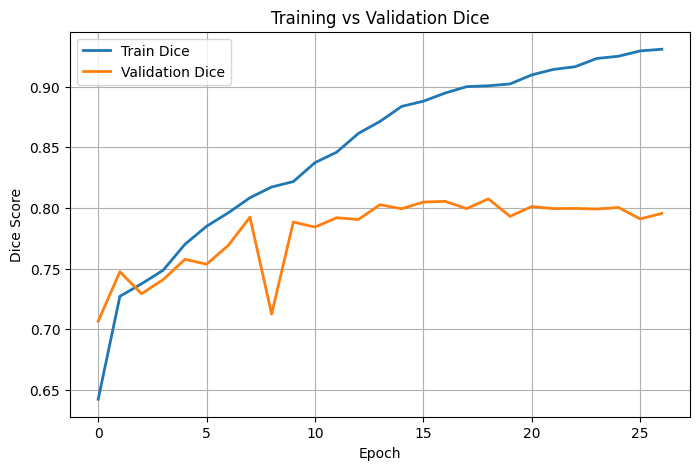

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history["train_dice"], label="Train Dice", linewidth=2)
plt.plot(history["val_dice"], label="Validation Dice", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Training vs Validation Dice")
plt.legend()
plt.grid(True)

plt.show()

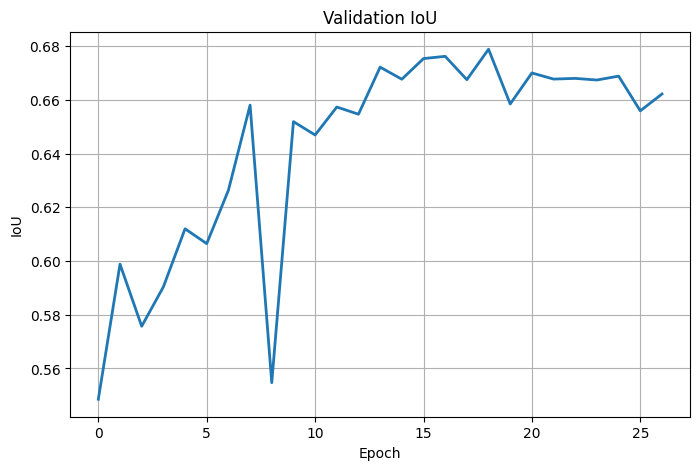

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history["val_iou"], linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("Validation IoU")
plt.grid(True)

plt.show()

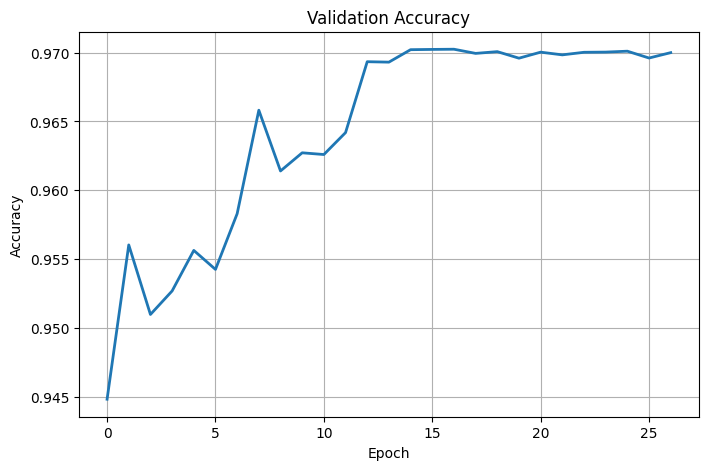

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history["accuracy"], linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.grid(True)

plt.show()

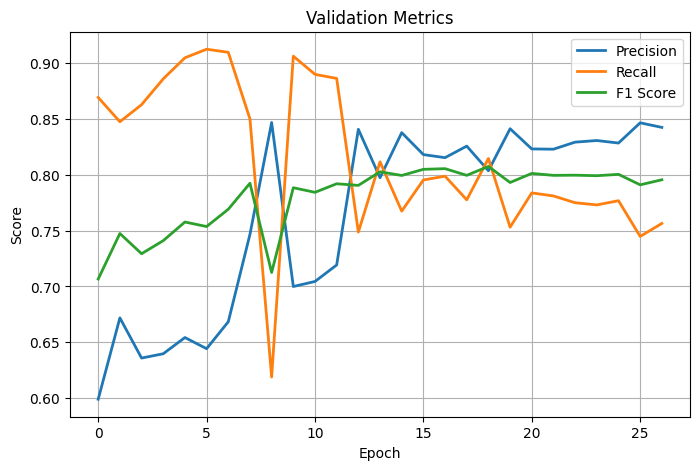

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history["precision"], label="Precision", linewidth=2)
plt.plot(history["recall"], label="Recall", linewidth=2)
plt.plot(history["f1"], label="F1 Score", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Metrics")
plt.legend()
plt.grid(True)

plt.show()

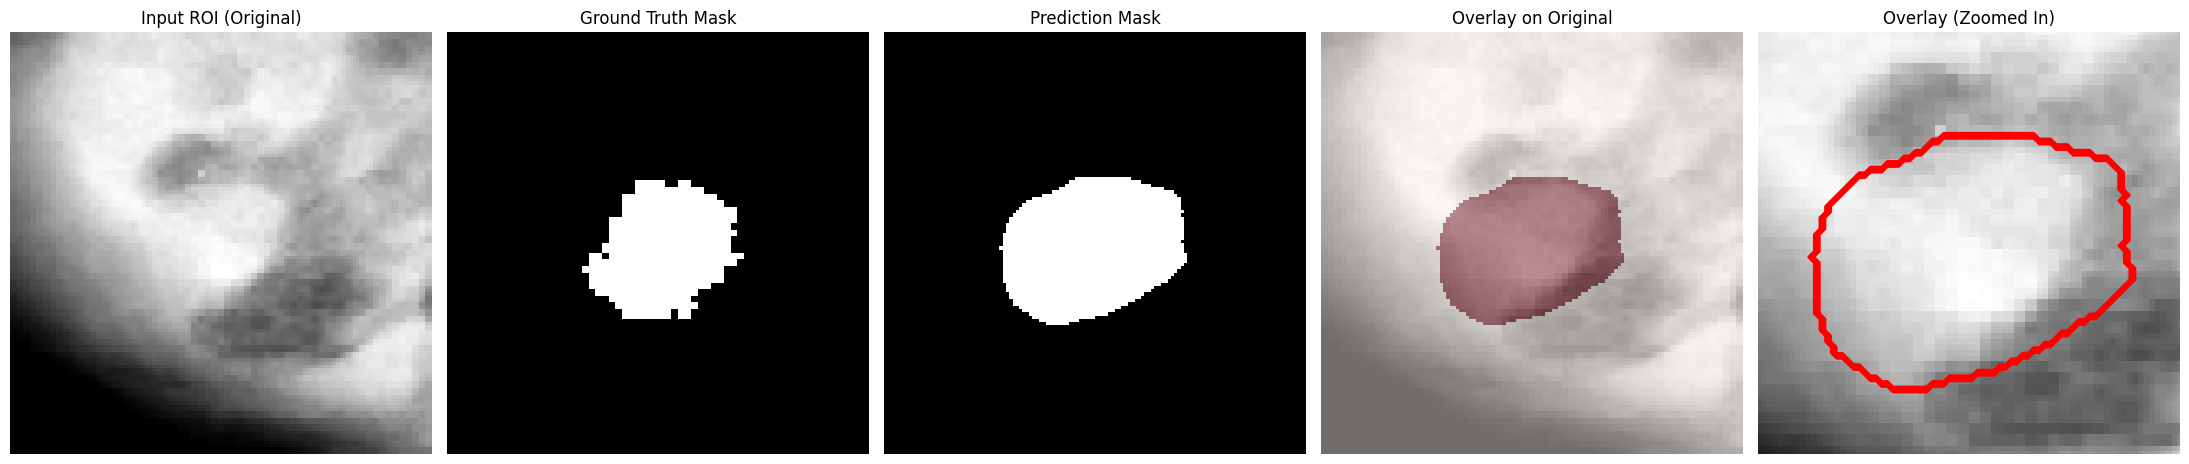

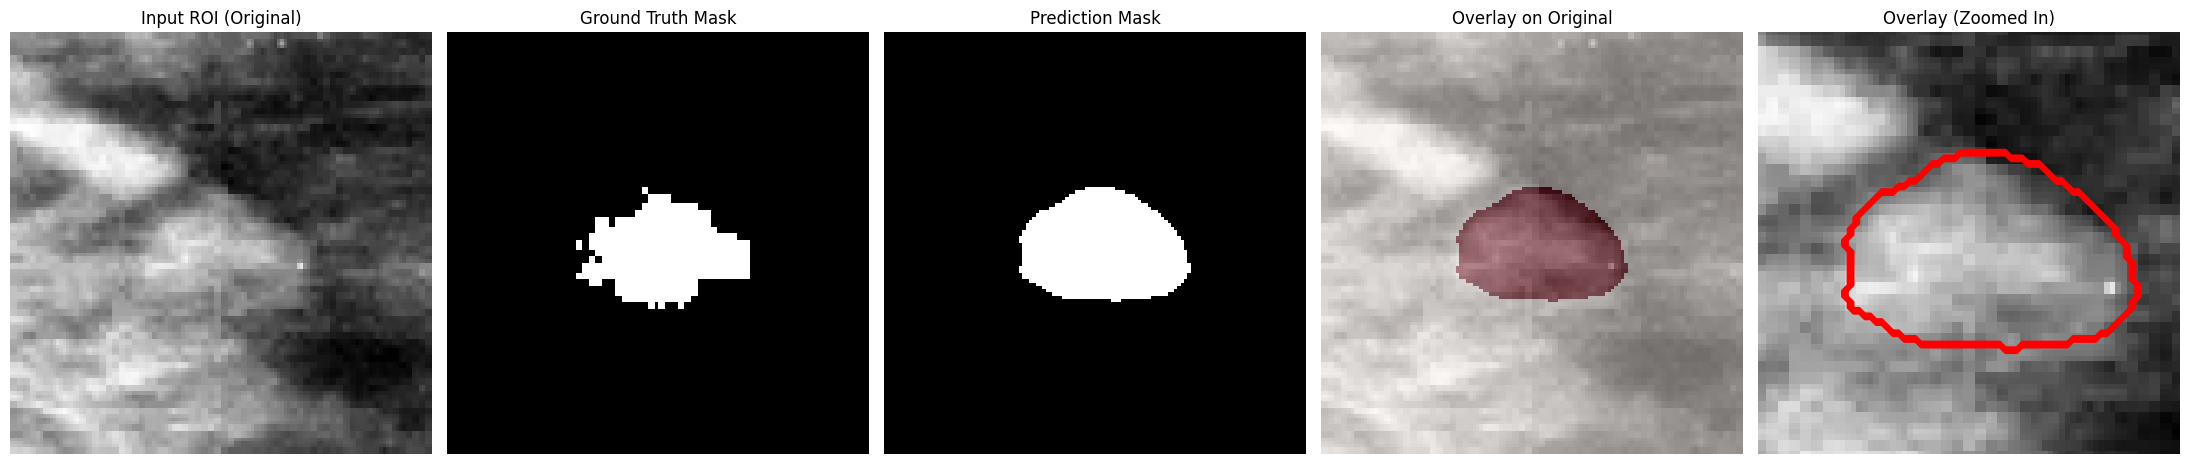

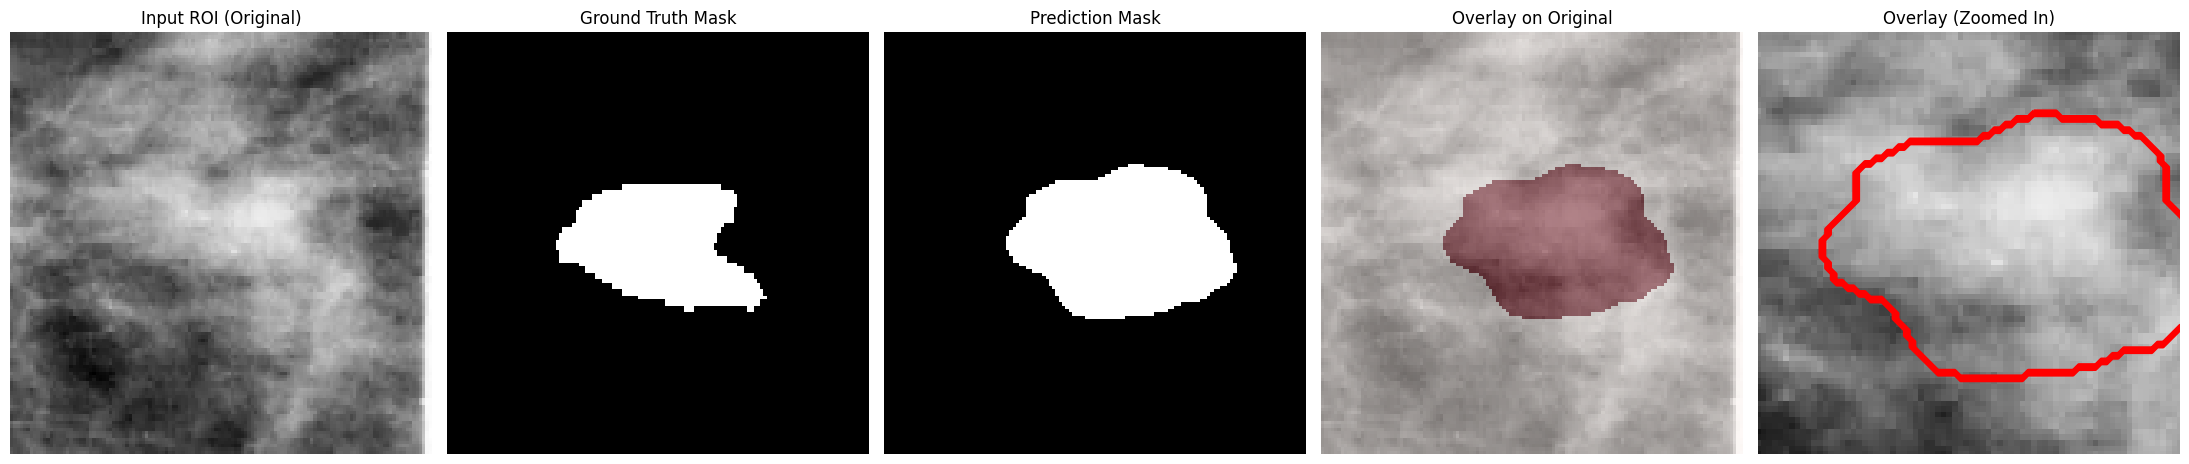

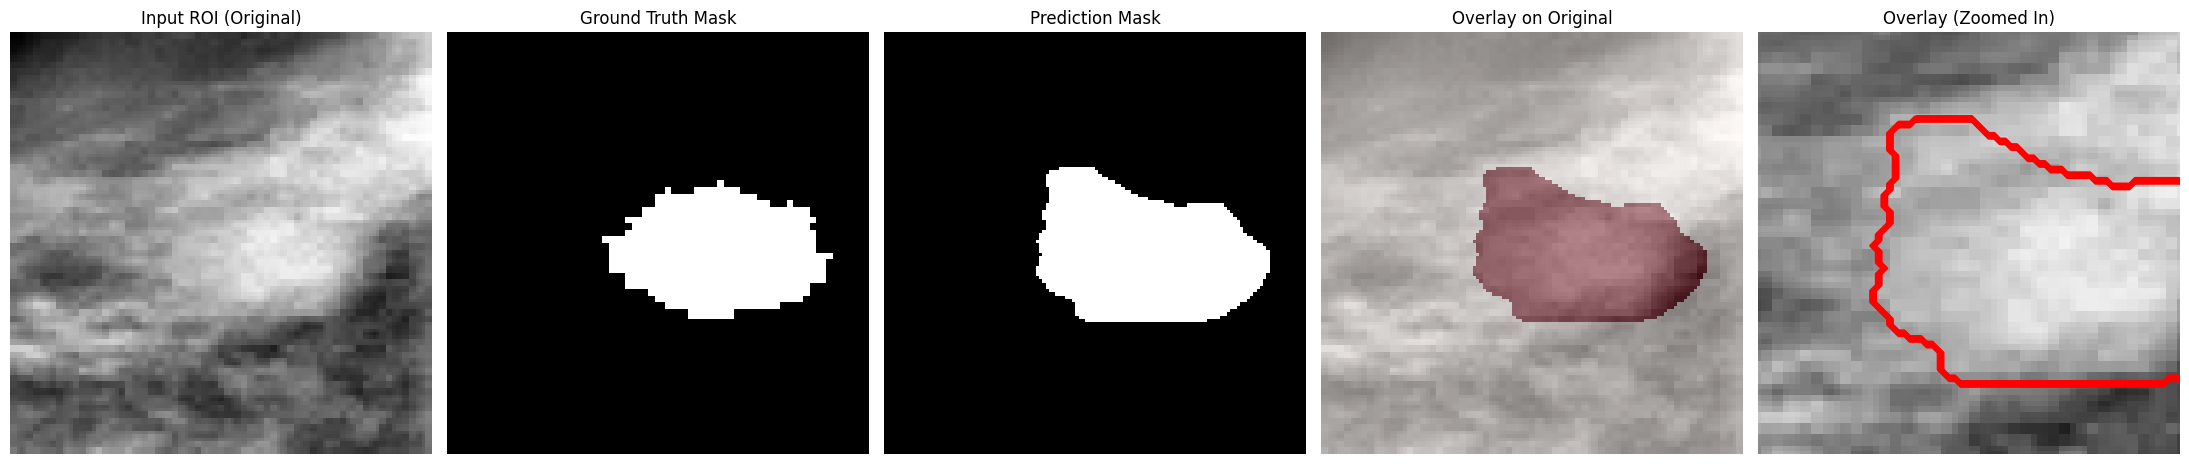

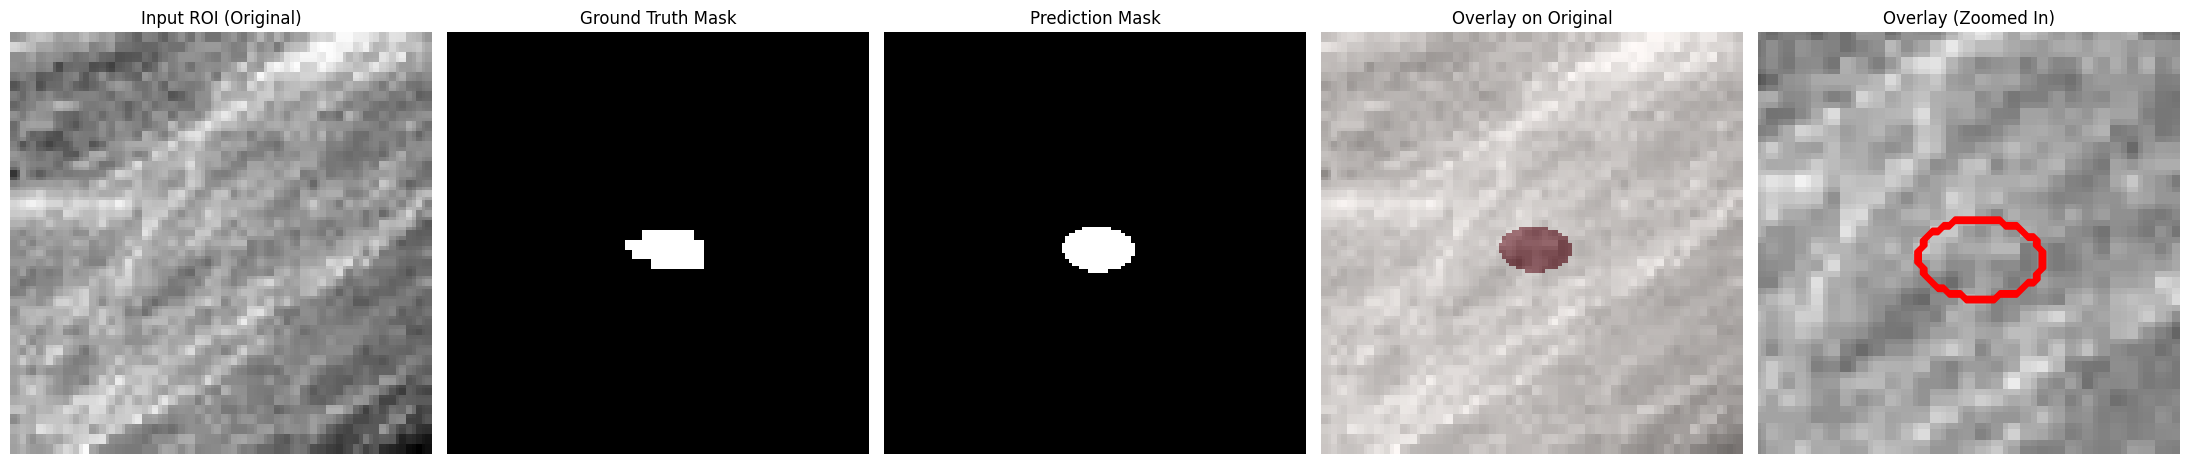

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

model.eval()

images, masks = next(iter(test_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = (torch.sigmoid(outputs) > 0.5).float()

num_images = 5

for i in range(num_images):

    img = images[i].cpu().squeeze().numpy()
    gt = masks[i].cpu().squeeze().numpy()
    pred = preds[i].cpu().squeeze().numpy()

    fig, ax = plt.subplots(1,5, figsize=(22,5))

    # -------------------------
    # 1. Original ROI
    # -------------------------
    ax[0].imshow(img, cmap='gray')
    ax[0].set_title("Input ROI (Original)")
    ax[0].axis('off')

    # -------------------------
    # 2. Ground Truth
    # -------------------------
    ax[1].imshow(gt, cmap='gray')
    ax[1].set_title("Ground Truth Mask")
    ax[1].axis('off')

    # -------------------------
    # 3. Prediction
    # -------------------------
    ax[2].imshow(pred, cmap='gray')
    ax[2].set_title("Prediction Mask")
    ax[2].axis('off')

    # -------------------------
    # 4. Overlay
    # -------------------------
    ax[3].imshow(img, cmap='gray')
    ax[3].imshow(pred, cmap='Reds', alpha=0.45)
    ax[3].set_title("Overlay on Original")
    ax[3].axis('off')

    # -------------------------
    # 5. Zoomed Overlay
    # -------------------------
    ax[4].imshow(img, cmap='gray')
    ax[4].contour(pred, colors='red', linewidths=2)
    ax[4].set_xlim(25,100)
    ax[4].set_ylim(100,25)
    ax[4].set_title("Overlay (Zoomed In)")
    ax[4].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd

# Create summary table
results = pd.DataFrame({

    "Metric": [
        "Loss",
        "Dice",
        "IoU",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Train": [
        min(history["train_loss"]),
        max(history["train_dice"]),
        "-",
        "-",
        "-",
        "-",
        "-"
    ],

    "Validation": [
        min(history["val_loss"]),
        max(history["val_dice"]),
        max(history["val_iou"]),
        max(history["accuracy"]),
        max(history["precision"]),
        max(history["recall"]),
        max(history["f1"])
    ],

    "Test": [
        test_loss,
        test_dice,
        test_iou,
        test_acc,
        test_precision,
        test_recall,
        test_f1
    ]

})

# Round values
results = results.round(4)

from IPython.display import display
display(results)

,Metric,Train,Validation,Test
0,Loss,0.1765,0.3765,0.4105
1,Dice,0.930742,0.8074,0.7975
2,IoU,-,0.6789,0.6681
3,Accuracy,-,0.9702,0.9681
4,Precision,-,0.8467,0.7885
5,Recall,-,0.9123,0.8105
6,F1 Score,-,0.8074,0.7975
